# Testing and improoving the ws_adaptive function

In [9]:
# --- IMPORT FUNCTIONS & PACKAGES ---
from pathlib import Path
import napari 
import sys
import tifffile
from lineagetree import LineageTree, read_from_mastodon
import numpy as np
from skimage.measure import regionprops
import matplotlib.pyplot as plt
from ipywidgets import IntSlider, interactive
from ipywidgets import Layout
import h5py
from scipy.ndimage import gaussian_filter, median_filter, grey_erosion
from skimage.filters import threshold_otsu, sobel
from skimage.segmentation import watershed

# CUSTOM FUNCTIONS
from watermasks.utils import paths, import_registration_mats_multiview, registered_position_of_id_in_t, paint_annotations, view_overlays_3d_V2

In [10]:
# --- PARAMETER SETTING ---
TP = 300
VIEW = '0'

In [ ]:
# --- IMPORT DATA AND FILES ---
path_h5, path_xml, path_mast, dir_input_images, dir_output_masks = paths()

# LOAD INPUT IMAGE
with h5py.File(path_h5, "r") as f5:
    test_image = f5[f't00{TP}']['s00']['2']['cells'][:]

# LOAD REG. MATRICES AND LINEAGETREE
R_of_t = import_registration_mats_multiview(path_xml, TP-5,TP+5)
lT = read_from_mastodon(path_mast)

shape_full_h5 = np.array([300, 1888, 2100]) # as measured in T7_3 data (dir = H:)
shape_test_image = np.array(np.shape(test_image))
scaling = shape_test_image/shape_full_h5
print(f'full image shape = {shape_full_h5}\n2nd h5 layer has shape = {shape_test_image} \n-scaling ratio is [z, y, x] = {scaling}')

# GET THE REGISTERED MASTODON POSITIONS
reg_pos_at_t = []
for mastodon_id_t in lT.time_nodes[TP]:
    x, y, z = registered_position_of_id_in_t(mastodon_id_t, lT, TP, R_of_t, VIEW, scaling)
    reg_pos_at_t.append([x, y, z])
reg_pos_at_t = np.asarray(reg_pos_at_t)

In [12]:
# --- VISUALIZE THE ANNOTATIONS ---
an_space = an_space = paint_annotations(TP, lT, shape_test_image,R_of_t,scaling,VIEW,2)

done painting


In [13]:
# --- IMAGE PRE-PROCESSING ---

# PARAMETERS
EROSION_RADIUS = 7 # after tweaking 

im = test_image
pos_array = np.array([p[::-1] for p in reg_pos_at_t]).round().astype(np.uint16)
im_gauss = gaussian_filter(im, sigma=1)
im_gauss_median = median_filter(im_gauss, size=1) # this seems that is not doing much! (inspection by eye)

erosion = grey_erosion(im_gauss_median, size=EROSION_RADIUS)
im_for_ws = im_gauss_median - erosion
im_ws_gauss = gaussian_filter(im_for_ws, sigma = 0.75)

In [14]:
# --- EDITING THE ADAPTIVE MASK LOOP ---

# PARAMETERS
INTENSITY_FLOOR = 50
MIX_RATIO=0.0 # after tweaking, it seems that it is not helping much.

# CREATE THE FIRST IGNORE MASK
ignore_mask = []
ignore_mask = im_gauss_median < INTENSITY_FLOOR
# Old way
# ignore_mask = (gradient < edge_thresh) & (im_gauss_median < intensity_floor) # why bring in the edge_thresh?

# THRESHOLDING
th_otsu = threshold_otsu(im_for_ws)
th = (1 - MIX_RATIO) * th_otsu + MIX_RATIO * np.mean(im_for_ws)
print(f'The Otsu treshold was caculated to be {th_otsu:.3g} \n')
if th > th_otsu:
    print(f"Threshold was elevated: \n {th_otsu:.3g} ----> {th:.3g}")
else:
    print(f"Threshold was lowered: \n {th_otsu:.3g} ----> {th:.3g}")


The Otsu treshold was caculated to be 236 

Threshold was lowered: 
 236 ----> 236


In [15]:
# # --- VISUALIZE THINGS THUS FAR ---
# %matplotlib widget
# view_overlays_3d_V2([test_image, im_gauss_median, erosion, im_for_ws, im_ws_gauss, ~ignore_mask], ['Original', 'Median(Gauss)', 'Erosion', 'Median - Erosion', 'Gauss(M - E)', 'Keep mask'],['gray', 'gray', 'viridis', 'gray', 'gray', 'binmap'], [1,1,1,1,1,0.5], same_contrast=False)

In [18]:
# GOOD FOR t = 300 , WS_IMAGE = Gauss(M - E)

starting_min_intensity=500 # min intensity value a the beggining of the loop
min_mask_floor_limit=10 # intensity is never accepted bellow this value
percent_of_th=100
min_th_vol=500
max_th_vol=1500
total_steps=10

pos_array = np.array([p[::-1] for p in reg_pos_at_t]).round().astype(np.uint16)
seeds = np.zeros_like(im)
seeds[tuple(pos_array.T)] = np.arange(1, len(reg_pos_at_t) + 1)
all_seeds = set(np.unique(seeds)) - {0}

volumes = {}
# Remove bad initialization

def get_mask(pct_, min_intensity_):
    thresh_val = max(th * (pct_ / 100), min_intensity_)
    print(f' Computational threshhold = {th * (pct_ / 100)}, Lowest allowed threshhold = {min_intensity_} Applied threshold = { max(th * (pct_ / 100), min_intensity_)}')
    return (im_for_ws > thresh_val) & (~ignore_mask) # returns True at positions where intensity is greater than the threshhold, if pixel should not be ignored according to original ignore_mask.

# FIRST WATERSHED, STARTING WITH 
ws = watershed(np.max(im_ws_gauss) - im_ws_gauss, seeds, mask=get_mask(100, starting_min_intensity))

# FIRST FILTERING
# Yes, it could be part of the main while loop.
unique, counts = np.unique_counts(ws)
vols = dict(zip(unique, counts))
for s, v in vols.items():
    if s != 0 and (v < min_th_vol or v > max_th_vol): # don't check the background
        ws[ws == s] = 0
ws0 = ws.copy()
# Visualize the initial, segmentation, OLNLY FOR TESTING

missed_seeds = all_seeds - set(np.unique(ws))
print("- starting missing:", len(missed_seeds))

pct_increment = 100/total_steps
inte_increment = (starting_min_intensity - min_mask_floor_limit)/total_steps

inc = 1 # for visualization reasons
for step in range(total_steps):
    if not missed_seeds:
        break

    mask = get_mask(percent_of_th, min_mask_floor_limit)
    new_ws = watershed(np.max(im_for_ws) - im_for_ws, seeds, mask=mask)

    unique, counts = np.unique_counts(new_ws)
    vols = dict(zip(unique, counts))

    for s in missed_seeds.intersection(vols.keys()):
        if s != 0 and min_th_vol < vols[s] < max_th_vol:
            ws[new_ws == s] = s

    if inc == 1:
        ws1 = ws.copy()
        # Visualize the first interation of th segmentation image, OLNY FOR TESTING

    missed_seeds = all_seeds - set(np.unique(ws))
    percent_of_th -= pct_increment
    inc+=1
    print("- missing:", len(missed_seeds))

 Computational threshhold = 236.0, Lowest allowed threshhold = 500 Applied threshold = 500
- starting missing: 351
 Computational threshhold = 236.0, Lowest allowed threshhold = 10 Applied threshold = 236.0
- missing: 125
 Computational threshhold = 212.4, Lowest allowed threshhold = 10 Applied threshold = 212.4
- missing: 105
 Computational threshhold = 188.8, Lowest allowed threshhold = 10 Applied threshold = 188.8
- missing: 91
 Computational threshhold = 165.2, Lowest allowed threshhold = 10 Applied threshold = 165.2
- missing: 73
 Computational threshhold = 141.6, Lowest allowed threshhold = 10 Applied threshold = 141.6
- missing: 50
 Computational threshhold = 118.0, Lowest allowed threshhold = 10 Applied threshold = 118.0
- missing: 39
 Computational threshhold = 94.4, Lowest allowed threshhold = 10 Applied threshold = 94.4
- missing: 29
 Computational threshhold = 70.8, Lowest allowed threshhold = 10 Applied threshold = 70.8
- missing: 17
 Computational threshhold = 47.2, Lowes

In [ ]:
# VISUALIZE RESULTS IN 3-D
viewer = napari.Viewer()
viewer.add_image(test_image)
viewer.add_image(an_space, colormap='green')
viewer.add_image(ws0)
viewer.add_image(ws1)
viewer.add_image(ws)
napari.run()

## Discussion

Compairing the results from the same angle with previous algorithm and the current one:

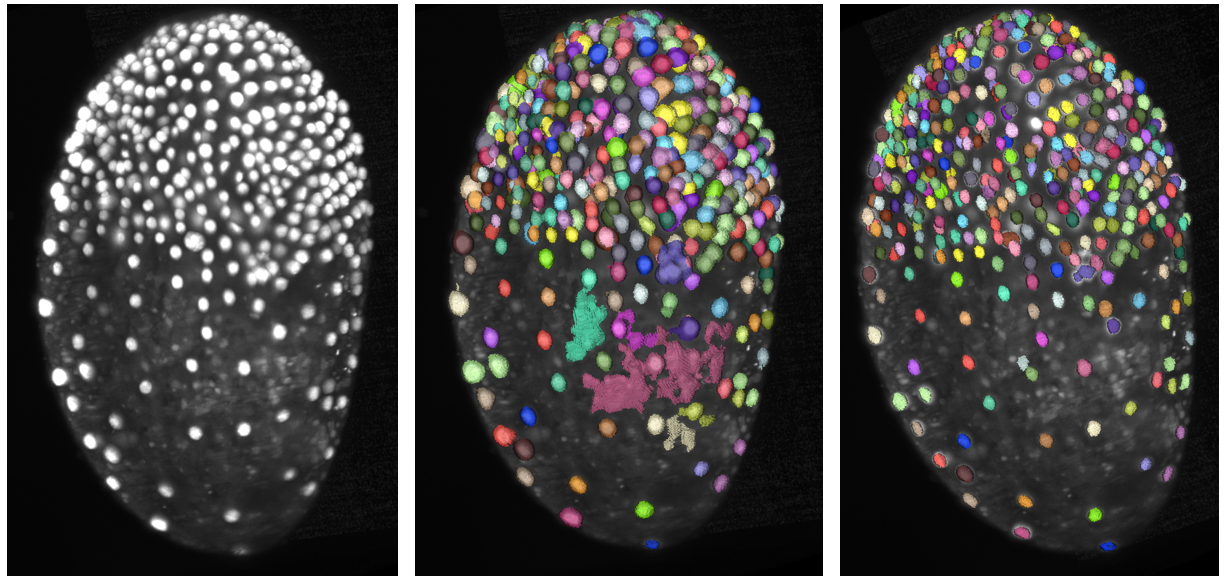

**Figure 1.** *Raw data (left), with _v2(middle), this implementation.*

Big regions are now filtered naturally by the code, but for some reason we are missing more cells (8 cells before, 18 now)... even a bright one, at the upper half of the embryo. Not sure if it is due to the parameters, anyhow, more improvements must be made.

Extra ideas for further experimentation:

**1.** Use a multi-Otsu thresh hold, as you have essentialy 3 categories of intensities:

**a.** very bright nuclei **b.**  midium intensity nuclei and autoflourecense **c.** background noise and very dim nuclei.

**2.** Use the sobel edge filter to get better results. You have already tried this with mid results, tweak more the parameters.

**3.** Use the deconvolved datasets instead.

**4** Appling to different timepoints, needs extra tweakng of the parameters. See if this can be automated using intensity statistics.